In [23]:
import pandas as pd
import torch



In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
df.shape

(10000, 14)

In [4]:
data =df.copy()

In [5]:
data 

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Preprocessing

In [6]:
drop_cols = ["RowNumber" , "CustomerId" ,"Surname"]
data =data.drop(columns = drop_cols )

In [7]:
data.shape

(10000, 11)

In [8]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

In [9]:

le = LabelEncoder()

In [10]:
data = pd.get_dummies(data , columns = ["Geography"] , drop_first  = True , dtype =int)

In [11]:
data["Gender"] = le.fit_transform(data["Gender"])

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  int64  
 11  Geography_Spain    10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


In [14]:
data.isnull().sum()

CreditScore          0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Geography_Germany    0
Geography_Spain      0
dtype: int64

In [15]:
X = data.drop(columns=['Exited'])
y = data["Exited"]

In [16]:
X.shape


(10000, 11)

In [17]:
X_train , X_test , y_train , y_test = train_test_split(
    X,y , test_size =.2 , random_state = 42
)

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## convert data into tensor

In [21]:
from torch.utils.data import TensorDataset , DataLoader

In [24]:
X_train_tensor =torch.tensor(X_train_scaled , dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_scaled , dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values , dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32)

In [25]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [26]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Buiding ANN

In [27]:
import torch 
import torch.nn as nn

In [28]:

class ANN(nn.Module):
    def __init__(self , ):
        super(ANN , self).__init__()
        self.model = nn.Sequential(
            # first layer
            nn.Linear(X.shape[1], 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self , x):
        x= self.model(x)
        return x

In [29]:
model=ANN()

## train model

In [30]:
import torch.optim as optim


criterion = nn.BCEWithLogitsLoss()
optimizer  = optim.Adam(model.parameters())

In [31]:
train_losses = []
val_losses = []
best_val_loss = float("inf")
epochs =200
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for xb , yb in train_loader:
        optimizer.zero_grad()
        yb = yb.float().view(-1, 1)
        outputs = model(xb)
        loss = criterion(outputs , yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    model.eval()
    running_val_loss  =0.0
    with torch.no_grad():  # no gradient computition
        for xb , yb in test_loader:
            yb = yb.float().view(-1, 1)
            outputs = model(xb)
            loss = criterion(outputs , yb)
            running_val_loss+= loss
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)
    
    train_loss = running_loss/(len(train_loader))
    
    print(f"epochs {epoch+1}/{epochs} & training loss {epoch_train_loss} &  val_Loss = {epoch_val_loss}")
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")

        
    
        

epochs 1/200 & training loss 0.7190313866138458 &  val_Loss = 0.6936659216880798
epochs 2/200 & training loss 0.6930839252471924 &  val_Loss = 0.6927443146705627
epochs 3/200 & training loss 0.6899665069580078 &  val_Loss = 0.6881946921348572
epochs 4/200 & training loss 0.6841755065917968 &  val_Loss = 0.6852992177009583
epochs 5/200 & training loss 0.682031307220459 &  val_Loss = 0.6850733757019043
epochs 6/200 & training loss 0.6809866285324097 &  val_Loss = 0.684352695941925
epochs 7/200 & training loss 0.6803992216587067 &  val_Loss = 0.6841326951980591
epochs 8/200 & training loss 0.6801094496250153 &  val_Loss = 0.6842136979103088
epochs 9/200 & training loss 0.6796412425041198 &  val_Loss = 0.6843283176422119
epochs 10/200 & training loss 0.6794385750293732 &  val_Loss = 0.683988630771637
epochs 11/200 & training loss 0.6790828976631165 &  val_Loss = 0.6843985319137573
epochs 12/200 & training loss 0.6788426806926727 &  val_Loss = 0.6840150952339172
epochs 13/200 & training los

## Evaluation

In [32]:
model.eval()
total = 0
correct = 0

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)              # shape: [batch_size, 1]
        probs = torch.sigmoid(outputs)   # convert logits to probabilities
        predicted = (probs >= 0.5).long().squeeze()  # 0 or 1

        correct += (predicted == yb).sum().item()
        total += yb.size(0)

accuracy = correct / total * 100
accuracy

19.650000000000002

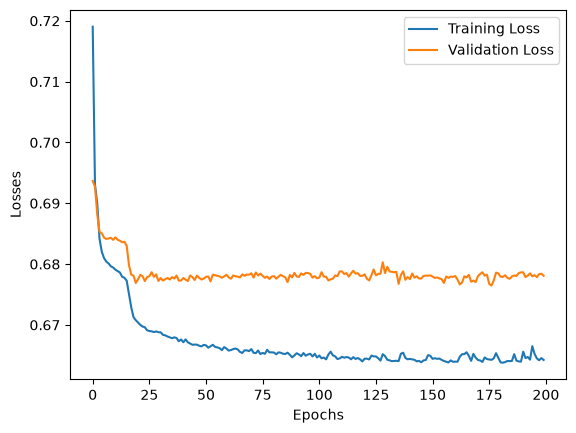

In [33]:
import matplotlib.pyplot as plt

loss_df = pd. DataFrame( {
"Training Loss": train_losses,
"Validation Loss": val_losses

})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()
plt.show()